<a href="https://colab.research.google.com/github/Anshu-kumar-singh/Store_Sales_Time_Series_Forecasting-ML-/blob/main/Store_Sales_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1 — Upload kaggle.json
# ============================================================
from google.colab import files
files.upload()  # select your kaggle.json file when prompted

{}

In [ ]:
# ============================================================
# CELL 2 — Setup Kaggle API
# ============================================================
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print("Kaggle API ready")

Kaggle API ready


In [ ]:
# ============================================================
# CELL 3 — Download + Unzip Dataset
# ============================================================
!kaggle competitions download -c store-sales-time-series-forecasting
!unzip -q store-sales-time-series-forecasting.zip
print("Files extracted")

100% 21.4M/21.4M [00:02<00:00, 9.60MB/s]

Files extracted


In [ ]:
# ============================================================
# CELL 4 — Load All CSV Files
# ============================================================
import pandas as pd

train        = pd.read_csv("train.csv",            parse_dates=["date"])
stores       = pd.read_csv("stores.csv")
holidays     = pd.read_csv("holidays_events.csv",  parse_dates=["date"])
oil          = pd.read_csv("oil.csv",              parse_dates=["date"])
transactions = pd.read_csv("transactions.csv",     parse_dates=["date"])

print("All files loaded")

All files loaded


In [ ]:

print("=== SHAPE ===")
print("train        :", train.shape)
print("stores       :", stores.shape)
print("holidays     :", holidays.shape)
print("oil          :", oil.shape)
print("transactions :", transactions.shape)


=== SHAPE ===
train        : (3000888, 6)
stores       : (54, 5)
holidays     : (350, 6)
oil          : (1218, 2)
transactions : (83488, 3)


In [ ]:
print(train.head())

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0


In [ ]:
print(stores.head())

   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4


In [ ]:
print(holidays.head())

        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  


In [ ]:
print(oil.head())

        date  dcoilwtico
0 2013-01-01         NaN
1 2013-01-02       93.14
2 2013-01-03       92.97
3 2013-01-04       93.12
4 2013-01-07       93.20


In [ ]:
print(transactions.head())

        date  store_nbr  transactions
0 2013-01-01         25           770
1 2013-01-02          1          2111
2 2013-01-02          2          2358
3 2013-01-02          3          3487
4 2013-01-02          4          1922


In [ ]:
# merge stores info
df = train.merge(stores, on="store_nbr", how="left")

# merge oil price
df = df.merge(oil, on="date", how="left")

# merge transactions
df = df.merge(transactions, on=["date", "store_nbr"], how="left")

# merge holidays
df = df.merge(holidays[["date", "type"]], on="date", how="left")

In [ ]:
print(df.head())

   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type_x  cluster  dcoilwtico  transactions   type_y  
0      D       13         NaN           NaN  Holiday  
1      D       13         NaN           NaN  Holiday  
2      D       13         NaN           NaN  Holiday  
3      D       13         NaN           NaN  Holiday  
4      D       13         NaN           NaN  Holiday  


In [ ]:
print(df.shape)

(3054348, 13)


In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 13 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type_x        object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  transactions  float64       
 12  type_y        object        
dtypes: datetime64[ns](1), float64(3), int64(4), object(5)
memory usage: 302.9+ MB
None


In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

# 🎯 Why We Are Doing This

Models cannot understand raw dates directly.

So we convert dates into:

year
month
day
weekday

This helps model learn patterns like:

weekend sales
monthly trends
yearly seasonality

In [ ]:
print(df.head())

   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  type_x  cluster  dcoilwtico  transactions   type_y  year  month  day  \
0      D       13         NaN           NaN  Holiday  2013      1    1   
1      D       13         NaN           NaN  Holiday  2013      1    1   
2      D       13         NaN           NaN  Holiday  2013      1    1   
3      D       13         NaN           NaN  Holiday  2013      1    1   
4      D       13         NaN           NaN  Holiday  2013      1    1   

   day_of_week  
0            1  
1            1  
2            1  


In [ ]:
# 1. rename confusing column names
df = df.rename(columns={
    "type_x"     : "store_type",
    "type_y"     : "holiday_type",
    "dcoilwtico" : "oil_price"
})

In [ ]:
print(df.head())

   id       date  store_nbr      family  sales  onpromotion   city      state  \
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1   1 2013-01-01          1   BABY CARE    0.0            0  Quito  Pichincha   
2   2 2013-01-01          1      BEAUTY    0.0            0  Quito  Pichincha   
3   3 2013-01-01          1   BEVERAGES    0.0            0  Quito  Pichincha   
4   4 2013-01-01          1       BOOKS    0.0            0  Quito  Pichincha   

  store_type  cluster  oil_price  transactions holiday_type  year  month  day  \
0          D       13        NaN           NaN      Holiday  2013      1    1   
1          D       13        NaN           NaN      Holiday  2013      1    1   
2          D       13        NaN           NaN      Holiday  2013      1    1   
3          D       13        NaN           NaN      Holiday  2013      1    1   
4          D       13        NaN           NaN      Holiday  2013      1    1   

   day_of_week  
0        

# Feature Engineering (Lag + Rolling Features)

In [ ]:

# STEP 1 — sort first (CRITICAL — never skip this)
df = df.sort_values(["store_nbr", "family", "date"]).reset_index(drop=True)

# STEP 2 — LAG FEATURES
df["lag_1"]   = df.groupby(["store_nbr", "family"])["sales"].shift(1)
df["lag_7"]   = df.groupby(["store_nbr", "family"])["sales"].shift(7)
df["lag_14"]  = df.groupby(["store_nbr", "family"])["sales"].shift(14)
df["lag_30"]  = df.groupby(["store_nbr", "family"])["sales"].shift(30)
df["lag_365"] = df.groupby(["store_nbr", "family"])["sales"].shift(365)

# STEP 3 — ROLLING FEATURES
df["rolling_mean_7"]  = df.groupby(["store_nbr", "family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(7).mean())

df["rolling_mean_30"] = df.groupby(["store_nbr", "family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(30).mean())

df["rolling_std_7"]   = df.groupby(["store_nbr", "family"])["sales"].transform(
                            lambda x: x.shift(1).rolling(7).std())

# STEP 4 — DROP rows where lag values are NaN
# (first 365 rows per store+family will have NaN — remove them)
df = df.dropna(subset=["lag_1", "lag_7", "lag_14",
                        "lag_30", "lag_365",
                        "rolling_mean_7", "rolling_mean_30",
                        "rolling_std_7"])

df = df.reset_index(drop=True)

# STEP 5 — VERIFY
print("Shape after feature engineering:", df.shape)
print("\nNull counts:\n", df.isnull().sum())
print("\nSample:")
print(df[["date", "store_nbr", "family", "sales",
          "lag_1", "lag_7", "rolling_mean_7",
          "rolling_std_7"]].head(10))

Shape after feature engineering: (2403918, 25)

Null counts:
 id                       0
date                     0
store_nbr                0
family                   0
sales                    0
onpromotion              0
city                     0
state                    0
store_type               0
cluster                  0
oil_price           755568
transactions        158202
holiday_type       1988712
year                     0
month                    0
day                      0
day_of_week              0
lag_1                    0
lag_7                    0
lag_14                   0
lag_30                   0
lag_365                  0
rolling_mean_7           0
rolling_mean_30          0
rolling_std_7            0
dtype: int64

Sample:
        date  store_nbr      family  sales  lag_1  lag_7  rolling_mean_7  \
0 2013-12-28          1  AUTOMOTIVE    4.0    6.0    5.0        2.142857   
1 2013-12-29          1  AUTOMOTIVE    0.0    4.0    0.0        2.000000   
2 2013-12-30 

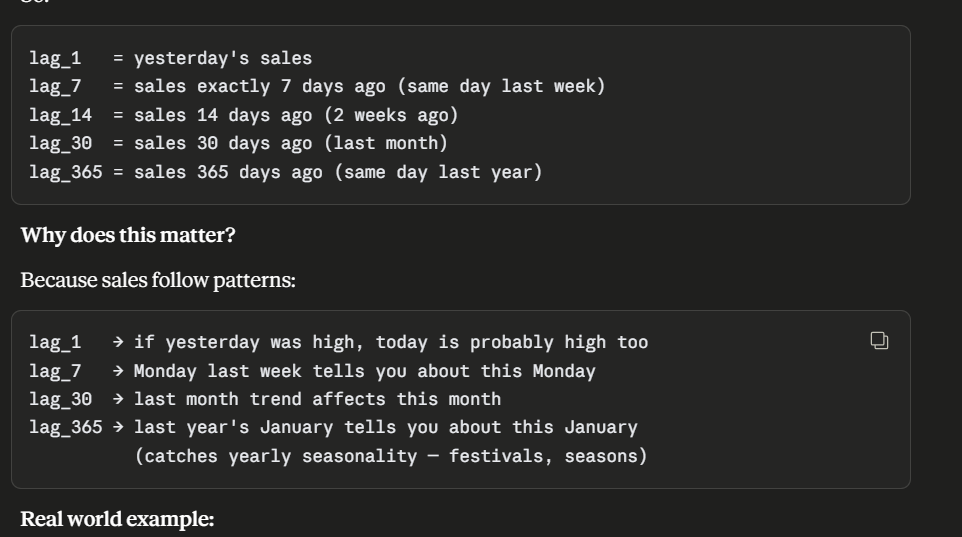

In [ ]:
print(df.head())


       id       date  store_nbr      family  sales  onpromotion   city  \
0  641520 2013-12-28          1  AUTOMOTIVE    4.0            0  Quito   
1  643302 2013-12-29          1  AUTOMOTIVE    0.0            0  Quito   
2  645084 2013-12-30          1  AUTOMOTIVE    1.0            0  Quito   
3  646866 2013-12-31          1  AUTOMOTIVE    2.0            0  Quito   
4  648648 2014-01-01          1  AUTOMOTIVE    0.0            0  Quito   

       state store_type  cluster  ...  day  day_of_week lag_1  lag_7  lag_14  \
0  Pichincha          D       13  ...   28            5   6.0    5.0     0.0   
1  Pichincha          D       13  ...   29            6   4.0    0.0     0.0   
2  Pichincha          D       13  ...   30            0   0.0    0.0     1.0   
3  Pichincha          D       13  ...   31            1   1.0    1.0     3.0   
4  Pichincha          D       13  ...    1            2   2.0    1.0     1.0   

   lag_30  lag_365  rolling_mean_7  rolling_mean_30  rolling_std_7  
0    

In [ ]:
print(df.isnull().sum())

id                       0
date                     0
store_nbr                0
family                   0
sales                    0
onpromotion              0
city                     0
state                    0
store_type               0
cluster                  0
oil_price           755568
transactions        158202
holiday_type       1988712
year                     0
month                    0
day                      0
day_of_week              0
lag_1                    0
lag_7                    0
lag_14                   0
lag_30                   0
lag_365                  0
rolling_mean_7           0
rolling_mean_30          0
rolling_std_7            0
dtype: int64


In [ ]:
df['oil_price'] = df['oil_price'].fillna(method='ffill')

/tmp/ipykernel_5866/3810549490.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['oil_price'] = df['oil_price'].fillna(method='ffill')


In [ ]:
df['transactions'] = df['transactions'].fillna(df['transactions'].median())

In [ ]:
df['holiday_type'] = df['holiday_type'].fillna('None')

In [ ]:
print(df.isnull().sum())

id                 0
date               0
store_nbr          0
family             0
sales              0
onpromotion        0
city               0
state              0
store_type         0
cluster            0
oil_price          2
transactions       0
holiday_type       0
year               0
month              0
day                0
day_of_week        0
lag_1              0
lag_7              0
lag_14             0
lag_30             0
lag_365            0
rolling_mean_7     0
rolling_mean_30    0
rolling_std_7      0
dtype: int64


In [ ]:
print(df.duplicated().sum())

4089


In [ ]:
duplicates = df[df.duplicated()]

print(duplicates.head())

           id       date  store_nbr     family  sales  onpromotion   city  \
1529   960499 2014-06-25          1  BABY CARE    0.0            0  Quito   
1530   960499 2014-06-25          1  BABY CARE    0.0            0  Quito   
1540   974755 2014-07-03          1  BABY CARE    0.0            0  Quito   
1899  1609147 2015-06-25          1  BABY CARE    0.0            0  Quito   
1900  1609147 2015-06-25          1  BABY CARE    0.0            0  Quito   

          state store_type  cluster  ...  day  day_of_week lag_1  lag_7  \
1529  Pichincha          D       13  ...   25            2   0.0    0.0   
1530  Pichincha          D       13  ...   25            2   0.0    0.0   
1540  Pichincha          D       13  ...    3            3   0.0    0.0   
1899  Pichincha          D       13  ...   25            3   0.0    0.0   
1900  Pichincha          D       13  ...   25            3   0.0    0.0   

      lag_14  lag_30  lag_365  rolling_mean_7  rolling_mean_30  rolling_std_7  
1529  

In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.select_dtypes(include='object').columns)

Index(['family', 'city', 'state', 'store_type', 'holiday_type'], dtype='object')


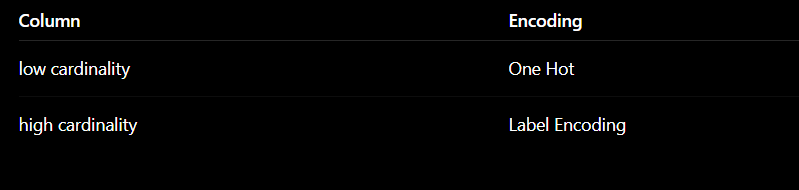

In [ ]:
for col in ['family', 'city', 'state', 'store_type', 'holiday_type']:
    print(col, ":", df[col].nunique())

family : 33
city : 22
state : 16
store_type : 5
holiday_type : 7


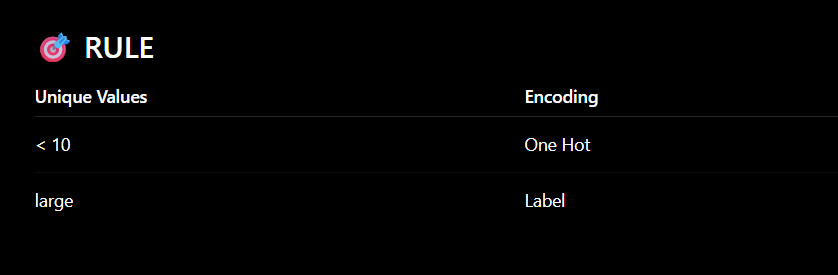

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_cols = ['family', 'city', 'state']

le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

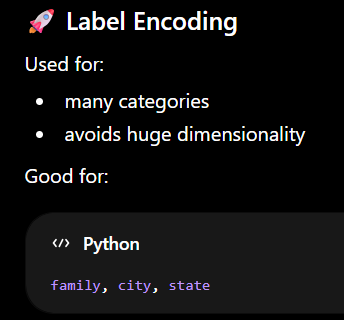

In [ ]:
df = pd.get_dummies(
    df,
    columns=['store_type', 'holiday_type'],
    drop_first=True
)

In [ ]:
print(df.head())

       id       date  store_nbr  family  sales  onpromotion  city  state  \
0  641520 2013-12-28          1       0    4.0            0    18     12   
1  643302 2013-12-29          1       0    0.0            0    18     12   
2  645084 2013-12-30          1       0    1.0            0    18     12   
3  646866 2013-12-31          1       0    2.0            0    18     12   
4  648648 2014-01-01          1       0    0.0            0    18     12   

   cluster  oil_price  ...  store_type_B  store_type_C  store_type_D  \
0       13        NaN  ...         False         False          True   
1       13        NaN  ...         False         False          True   
2       13      98.90  ...         False         False          True   
3       13      98.17  ...         False         False          True   
4       13      98.17  ...         False         False          True   

   store_type_E  holiday_type_Bridge  holiday_type_Event  \
0         False                False              

In [ ]:
print(df.shape)

(2399829, 33)


In [ ]:
print(df['oil_price'].isnull().sum())

2


In [ ]:
df['oil_price'] = df['oil_price'].ffill()
df['oil_price'] = df['oil_price'].bfill()

In [ ]:
print(df.head())

       id       date  store_nbr  family  sales  onpromotion  city  state  \
0  641520 2013-12-28          1       0    4.0            0    18     12   
1  643302 2013-12-29          1       0    0.0            0    18     12   
2  645084 2013-12-30          1       0    1.0            0    18     12   
3  646866 2013-12-31          1       0    2.0            0    18     12   
4  648648 2014-01-01          1       0    0.0            0    18     12   

   cluster  oil_price  ...  store_type_B  store_type_C  store_type_D  \
0       13      98.90  ...         False         False          True   
1       13      98.90  ...         False         False          True   
2       13      98.90  ...         False         False          True   
3       13      98.17  ...         False         False          True   
4       13      98.17  ...         False         False          True   

   store_type_E  holiday_type_Bridge  holiday_type_Event  \
0         False                False              

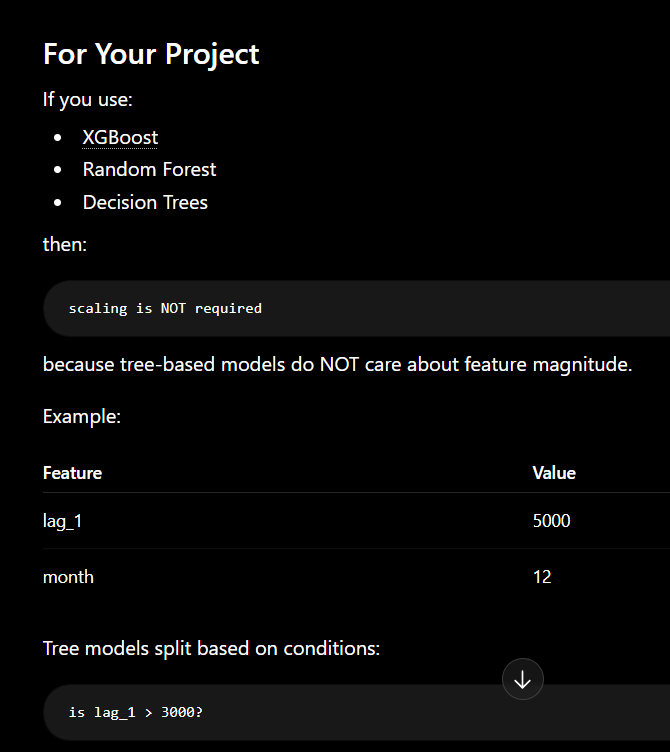

In [ ]:
# STEP 1: Drop rows with null lag features (first 7 days have NaN lags)
df = df.dropna()

# STEP 2: Set your split date (check your data range first)
print(df['date'].min())  # When does data start?
print(df['date'].max())  # When does data end?

# STEP 3: Split chronologically
# Use ~80-20 split based on dates
split_date = '2017-01-01'  # Change based on YOUR data range
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

# STEP 4: Separate features (X) from target (y)
X_train = train_df.drop(['date', 'sales'], axis=1)
y_train = train_df['sales']

X_test = test_df.drop(['date', 'sales'], axis=1)
y_test = test_df['sales']

# STEP 5: Verify shapes
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Date ranges - Train: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Date ranges - Test:  {test_df['date'].min()} to {test_df['date'].max()}")

2013-12-28 00:00:00
2017-08-15 00:00:00
Train: (2399829, 31), Test: (0, 31)
Date ranges - Train: 2013-12-28 00:00:00 to 2017-08-15 00:00:00
Date ranges - Test:  NaT to NaT


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# OPTION 1: Quick model (Random Forest - trains fast)
#model = RandomForestRegressor(
#    n_estimators=100,
#    max_depth=15,
#    n_jobs=-1,
#    random_state=42
#)

# OPTION 2: Better model (XGBoost - more accurate)
model = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    random_state=42
)

# Train
print("Training...")
model.fit(X_train, y_train)
print("✅ Training complete!")

# Predict
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mape = mean_absolute_percentage_error(y_test, y_pred_test)

print(f"\n📊 Results:")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2%}")

Training...
✅ Training complete!

📊 Results:
MAE:  $66.14
RMSE: $255.96
MAPE: 723416209705122432.00%
